In [8]:
#HW4 STAT 604 Duncan Newman

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

# Inverse CDF sampler: F(x) = 1 - theta/x  =>  x = theta / (1 - U)
def sample_inverse_cdf(theta, n):
    U = np.random.uniform(0, 1, n)
    return theta / (1 - U)

In [9]:
# Part a

theta = 2
n = 50

sample_a = sample_inverse_cdf(theta, n)
print("Sample (n=50) with theta=2:")
print(sample_a)

Sample (n=50) with theta=2:
[  6.58911684   2.80166719   2.58682501   4.45746787   7.1293361
   3.46684416 103.97279198   6.34577638   3.85305898   3.29010962
   3.04496507   7.38142772   3.56234615   2.12693075   3.32250339
   7.63345393   2.44645843   2.42557063   4.2694116    4.27193048
   5.47047386  13.28301674   7.25835111   5.14169893   7.20573704
   2.95403047   3.13375815   2.59155723   2.83171425   5.41970352
   2.20289777   3.53170429   3.51409093   3.95011087   3.48329068
   2.9080809    3.48645438  18.75981897  35.81663059   4.01474758
   5.31848344   2.26146721   2.92948216   3.41778808  14.95988782
   2.66828673   3.86872835 138.5020988    4.162202     5.16655055]


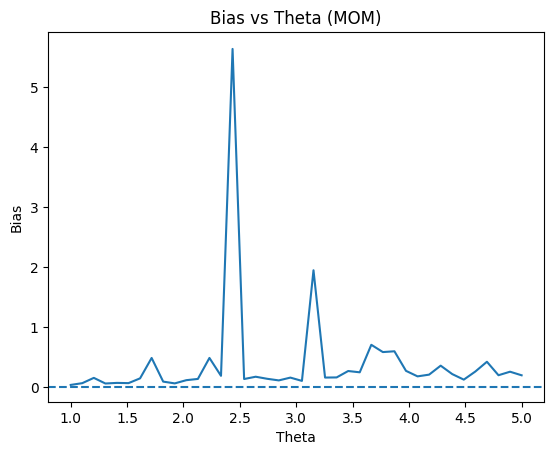

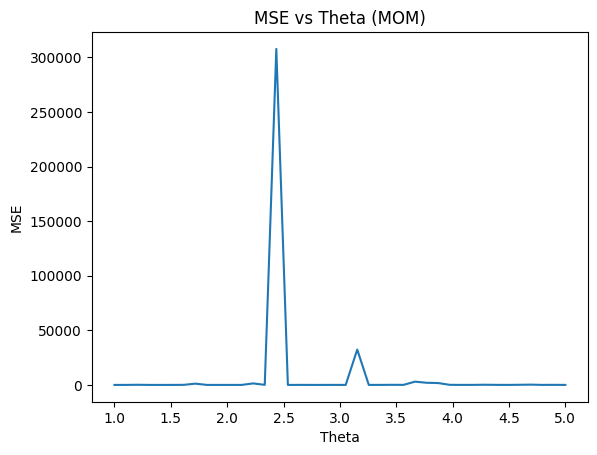

In [10]:
# Part b

np.random.seed(123)

# Inverse CDF sampler (single sample)
def sample_inverse_cdf(theta, n):
    U = np.random.uniform(0, 1, n)
    return theta / (1 - U)

# MOM estimator
def theta_mom(x):
    return (np.sum(np.sqrt(x)) / (2 * len(x))) ** 2

n = 50
B = 10000
theta_vals = np.linspace(1, 5, 40)

bias_mom = []
mse_mom = []

for theta in theta_vals:
    mean_est = 0.0
    mean_sq_est = 0.0

    for b in range(B):
        x = sample_inverse_cdf(theta, n)
        est = theta_mom(x)

        mean_est += est
        mean_sq_est += est**2

    mean_est /= B
    mean_sq_est /= B

    bias_mom.append(mean_est - theta)
    mse_mom.append(mean_sq_est - 2*theta*mean_est + theta**2)

# Plot Bias
plt.figure()
plt.plot(theta_vals, bias_mom)
plt.axhline(0, linestyle='--')
plt.xlabel('Theta')
plt.ylabel('Bias')
plt.title('Bias vs Theta (MOM)')
plt.show()

# Plot MSE
plt.figure()
plt.plot(theta_vals, mse_mom)
plt.xlabel('Theta')
plt.ylabel('MSE')
plt.title('MSE vs Theta (MOM)')
plt.show()

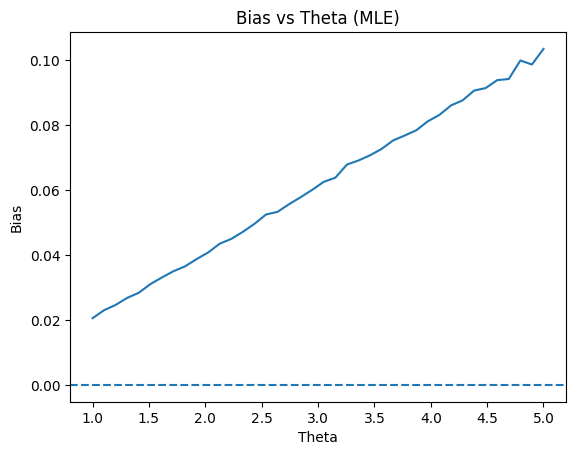

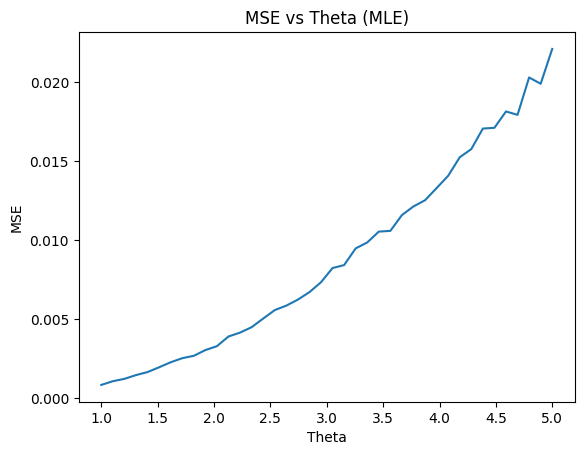

In [11]:
# Part c

def theta_mle(x):
    return np.min(x)

bias_mle = []
mse_mle = []
theta_vals = np.linspace(1, 5, 40)

for theta in theta_vals:
    estimates = np.zeros(B)

    for b in range(B):
        x = sample_inverse_cdf(theta, n)
        estimates[b] = theta_mle(x)

    bias_mle.append(np.mean(estimates) - theta)
    mse_mle.append(np.mean((estimates - theta) ** 2))

bias_mle = np.array(bias_mle)
mse_mle = np.array(mse_mle)

# Plot Bias (MLE)
plt.figure()
plt.plot(theta_vals, bias_mle)
plt.axhline(0, linestyle='--')
plt.xlabel('Theta')
plt.ylabel('Bias')
plt.title('Bias vs Theta (MLE)')
plt.show()

# Plot MSE (MLE)
plt.figure()
plt.plot(theta_vals, mse_mle)
plt.xlabel('Theta')
plt.ylabel('MSE')
plt.title('MSE vs Theta (MLE)')
plt.show()

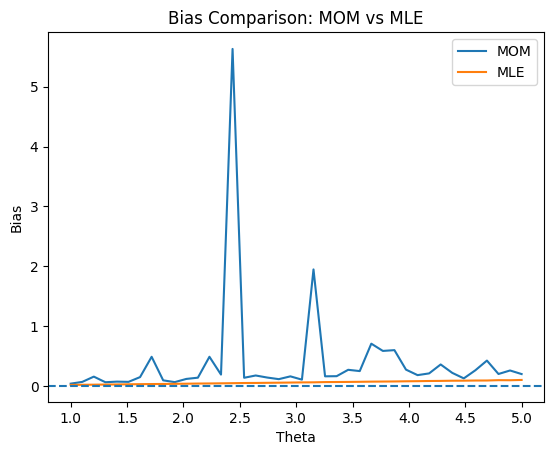

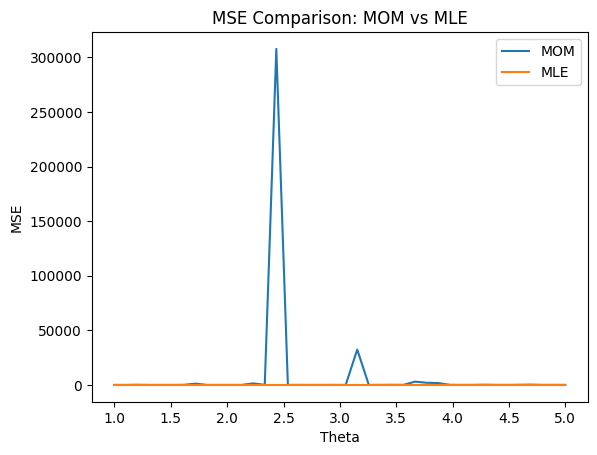

In [12]:
# Part d

plt.figure()
plt.plot(theta_vals, bias_mom, label='MOM')
plt.plot(theta_vals, bias_mle, label='MLE')
plt.axhline(0, linestyle='--')
plt.xlabel('Theta')
plt.ylabel('Bias')
plt.title('Bias Comparison: MOM vs MLE')
plt.legend()
plt.show()

# Combined MSE plot
plt.figure()
plt.plot(theta_vals, mse_mom, label='MOM')
plt.plot(theta_vals, mse_mle, label='MLE')
plt.xlabel('Theta')
plt.ylabel('MSE')
plt.title('MSE Comparison: MOM vs MLE')
plt.legend()
plt.show()